<h1 align="center"> TP : Principal Component Analysis </h1>

<pre align="left"> January 21th 2026               <i> </i>               <i> Answers: Mohamed Yassine Khales </i></pre>
* * *

In [33]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1


In [87]:
def rmvt(mu, Sigma, free_deg, num_points):
    Z = np.random.multivariate_normal(np.zeros_like(mu), Sigma, size=num_points)
    W = np.random.chisquare(free_deg, (num_points,len(mu)))
    X = mu+np.sqrt(free_deg/W)*Z
    return X

<Figure size 640x480 with 0 Axes>

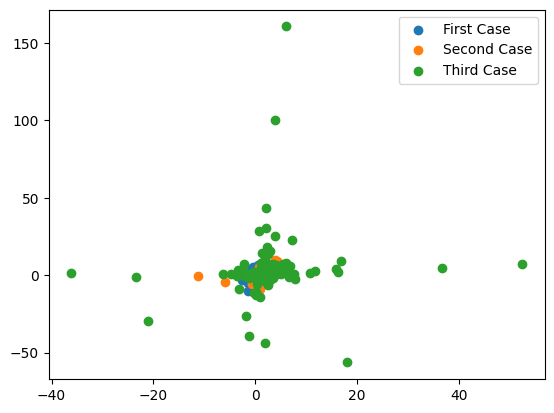

<Figure size 640x480 with 0 Axes>

In [88]:
# Test

mu = [0,0]; Sigma = [[1,1], [1,4]]; free_deg = 5; num_points = 100
X = rmvt(mu, Sigma, free_deg, num_points)
plt.scatter(X[:,0], X[:,1], label = "First Case")

mu = [2,2]; Sigma = [[1,1], [1,4]]; free_deg = 3; num_points = 100
X = rmvt(mu, Sigma, free_deg, num_points)
plt.scatter(X[:,0], X[:,1], label = "Second Case")

mu = [2,2]; Sigma = [[4,4], [4,16]]; free_deg = 1; num_points = 100
X = rmvt(mu, Sigma, free_deg, num_points)
plt.scatter(X[:,0], X[:,1], label="Third Case")

plt.legend()
plt.figure()




## Question 2

In [90]:
X = rmvt([0,0,0], [[1,1,1],[1,4,4], [1,4,9]], 5, 1000)

# Projection and normalization
proj_matrix = np.array([[1,1,1,1,1],[1,-1,1,-1,0],[0,-1,-1,0,2]])
print(X.shape)
print(proj_matrix.shape)
projected_X = X @ proj_matrix
final_X = projected_X / projected_X.max(axis=0)

# Shifting
shifting = np.array([[1,2,3,4,5]]*len(final_X))
final_X = final_X+shifting

# Noising
mu_noise = [0,0,0,0,0]
sigma_noise = np.diag([0.025, 0.025,0.025,0.025,0.025])
noise = np.random.multivariate_normal(mu_noise, sigma_noise, len(final_X))
X = final_X + noise

(1000, 3)
(3, 5)


## Question 3

## First method : I tried implementing it myself

In [102]:
Xc = (X-np.mean(X,axis=0))/np.std(X,axis=0)
def PCA(X):
    A = Xc.T @ Xc
    eig_values, Q = np.linalg.eigh(A)
    print(f"Explained Variances : {eig_values}")
    print(f"Singular values : {np.sqrt(eig_values)}")
    v1 = Q[:,-1]
    return v1
v1=PCA(Xc)
print(f"Principal Components : {v1}")
X_final = Xc @v1
print(v1)

Explained Variances : [ 336.62844059  442.80645784  656.6912668  1185.08925058 2378.78458419]
Singular values : [18.34743689 21.04296694 25.62598811 34.42512528 48.77278528]
Principal Components : [-0.48366211  0.53142942  0.13256008  0.44348174 -0.51904288]
[-0.48366211  0.53142942  0.13256008  0.44348174 -0.51904288]


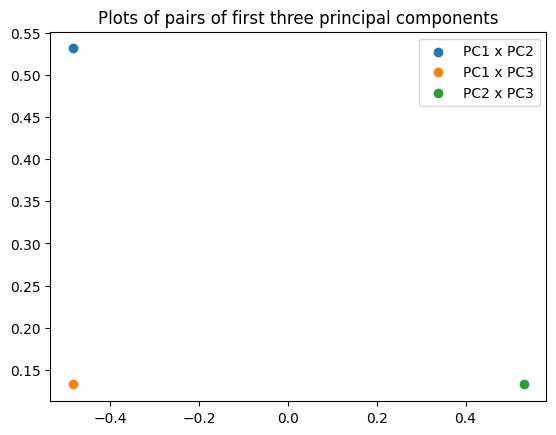

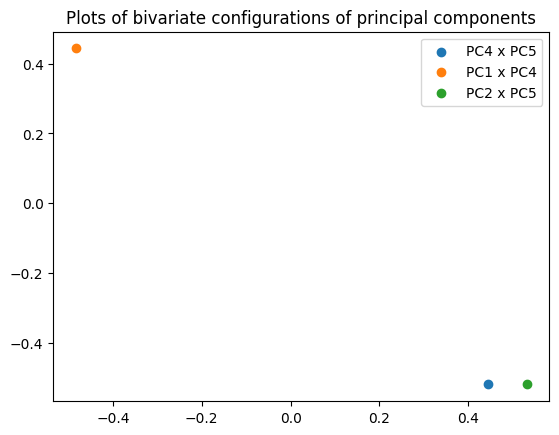

In [100]:
plt.scatter(v1[0], v1[1], label="PC1 x PC2")
plt.scatter(v1[0], v1[2], label="PC1 x PC3")
plt.scatter(v1[1], v1[2], label="PC2 x PC3")
plt.title("Plots of pairs of first three principal components")
plt.legend()
plt.show()

plt.figure()
plt.scatter(v1[3], v1[4], label="PC4 x PC5")
plt.scatter(v1[0], v1[3], label="PC1 x PC4")
plt.scatter(v1[1], v1[4], label="PC2 x PC5")
plt.title("Plots of bivariate configurations of principal components")
plt.legend()
plt.show()

## Second method : Importing PCA

In [103]:
from sklearn.decomposition import PCA

In [106]:
pca = PCA()
pca.fit(X)
comp=pca.components_

In [108]:
print(comp)

[[ 0.63325839 -0.40962423 -0.05538504 -0.36049409  0.5460479 ]
 [ 0.50224259  0.23286107  0.69976804 -0.14002414 -0.4292389 ]
 [ 0.31070083  0.24541399  0.09531072  0.8299016   0.38133471]
 [-0.46764006 -0.42070463  0.6965094   0.06356724  0.33934385]
 [-0.17752169  0.7353661   0.11422659 -0.39706396  0.50696671]]
